# Agentic RAG — Results Analysis

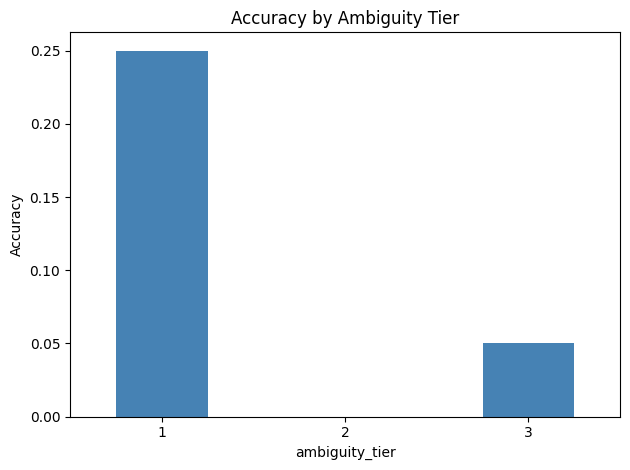

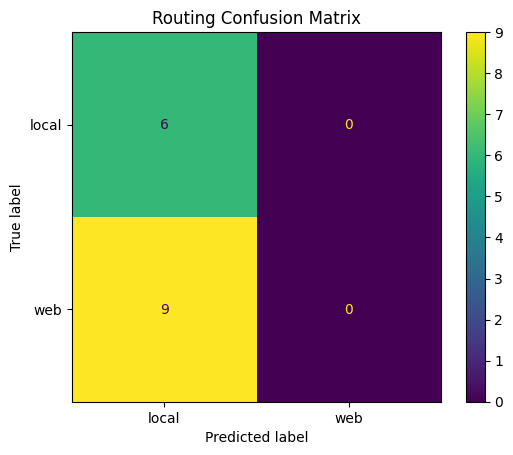

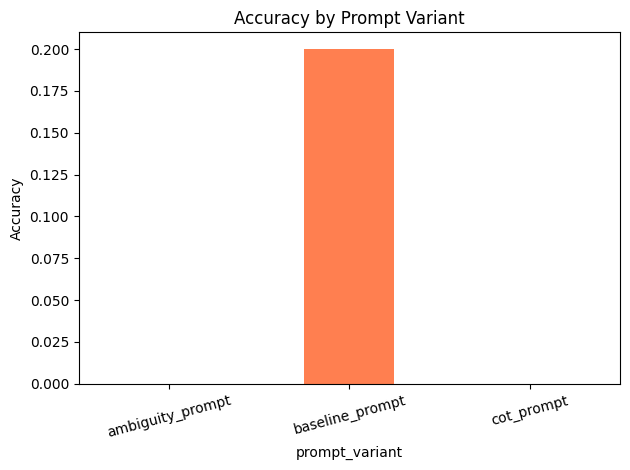

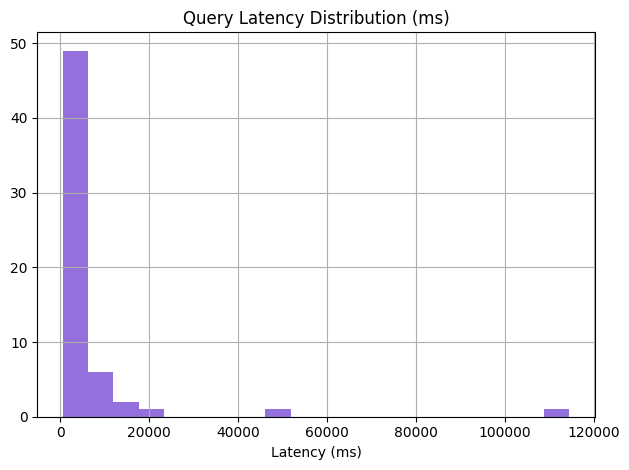


Total failures: 54 / 60
   query_id                                        prompt_text  \
5      Q006                          What AI news broke today?   
6      Q007         What is the current stock price of NVIDIA?   
7      Q008   Who won the most recent AI research competition?   
8      Q009                What did OpenAI announce this week?   
9      Q010  What are the latest updates to the LangChain l...   
10     Q011    What are recent advances in transformer models?   
11     Q012           How is RAG being used in industry today?   
12     Q013  What is the current state of vector database t...   
13     Q014        How has LLM performance improved over time?   
15     Q001            What is retrieval-augmented generation?   
16     Q002  Explain the difference between dense and spars...   
17     Q003  What embedding model does ChromaDB use by defa...   
18     Q004  Describe the architecture of a transformer model.   
19     Q005     What is LangGraph used for in agent

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../results/routing_log_llama3.csv")

# 1. Accuracy by ambiguity tier (column is ambiguity_tier, not ambiguity_level)
df.groupby("ambiguity_tier")["correct"].mean().plot(
    kind="bar", title="Accuracy by Ambiguity Tier", color="steelblue"
)
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. Confusion matrix of tool routing
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(df["ground_truth"], df["predicted_tool"],
                      labels=["local_retrieval", "web_search"])
ConfusionMatrixDisplay(cm, display_labels=["local", "web"]).plot()
plt.title("Routing Confusion Matrix")
plt.show()

# 3. Accuracy by prompt variant
df.groupby("prompt_variant")["correct"].mean().plot(
    kind="bar", title="Accuracy by Prompt Variant", color="coral"
)
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 4. Latency distribution
df["latency_ms"].hist(bins=20, color="mediumpurple")
plt.title("Query Latency Distribution (ms)")
plt.xlabel("Latency (ms)")
plt.tight_layout()
plt.show()

# 5. Failure analysis
failures = df[df["correct"] == False]
print(f"\nTotal failures: {len(failures)} / {len(df)}")
print(failures[["query_id", "prompt_text", "ground_truth", "predicted_tool", "ambiguity_tier"]])